#  Аналіз ринку ноутбуків на базі 3 магазинів (Foxtrot. Telemart. Brain)

# Підготовка даних

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re

## Завантажуємо дані

In [4]:
foxtrot = pd.read_csv(r"D:\projects\Mega-laptop-parser\data\foxtrot_data.csv")
brain = pd.read_csv(r"D:\projects\Mega-laptop-parser\data\brain_data.csv")
telemart = pd.read_csv(r"D:\projects\Mega-laptop-parser\data\telemart_data.csv")
cpu_rating = pd.read_csv(r"D:\projects\Mega-laptop-parser\data\technical_city_cpu.csv")
gpu_rating = pd.read_csv(r"D:\projects\Mega-laptop-parser\data\technical_city_gpu.csv")

In [5]:
foxtrot = pd.DataFrame(foxtrot)
brain = pd.DataFrame(brain)
telemart = pd.DataFrame(telemart)
cpurating = pd.DataFrame(cpu_rating)
gpurating = pd.DataFrame(gpu_rating)

### Стандартизація датафрейму

#### Foxtrot

In [6]:
foxtrot.info()

<class 'pandas.DataFrame'>
RangeIndex: 840 entries, 0 to 839
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   full_name     840 non-null    str    
 1   price         840 non-null    float64
 2   product_code  840 non-null    float64
 3   shop          840 non-null    str    
 4   product_url   840 non-null    str    
 5   cpu           840 non-null    str    
 6   gpu           835 non-null    str    
 7   other         840 non-null    str    
dtypes: float64(2), str(6)
memory usage: 52.6 KB


In [7]:
def full_name(name: str, l: list):
    if not isinstance(name, str):
        return name
    
    name = name.strip()
    pattern = rf"\b{re.escape(name)}\b"

    # Шукаємо повнішу назву у рейтингу
    for full_name in l:
        if isinstance(full_name, str) and re.search(pattern.lower(), full_name.lower()):
            return full_name
    
    return name

In [8]:
cpulist = cpu_rating['full_name'].tolist()
foxtrot['cpu'] = foxtrot['cpu'].apply(lambda x: full_name(x, cpulist))
foxtrot['product_code'] = foxtrot['product_code'].astype(int).astype(str)
foxtrot.info()

<class 'pandas.DataFrame'>
RangeIndex: 840 entries, 0 to 839
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   full_name     840 non-null    str    
 1   price         840 non-null    float64
 2   product_code  840 non-null    str    
 3   shop          840 non-null    str    
 4   product_url   840 non-null    str    
 5   cpu           840 non-null    str    
 6   gpu           835 non-null    str    
 7   other         840 non-null    str    
dtypes: float64(1), str(7)
memory usage: 52.6 KB


#### Brain

In [9]:
brain.info()

<class 'pandas.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   full_name     480 non-null    str    
 1   price         480 non-null    float64
 2   product_code  480 non-null    str    
 3   shop          480 non-null    str    
 4   product_url   480 non-null    str    
 5   cpu           480 non-null    str    
 6   gpu           480 non-null    str    
 7   other         480 non-null    str    
dtypes: float64(1), str(7)
memory usage: 30.1 KB


#### Telemart

In [10]:
telemart.info()
telemart['product_code'] = telemart['product_code'].astype(int).astype(str)

<class 'pandas.DataFrame'>
RangeIndex: 735 entries, 0 to 734
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   full_name     735 non-null    str    
 1   price         735 non-null    float64
 2   product_code  735 non-null    float64
 3   shop          735 non-null    str    
 4   product_url   735 non-null    str    
 5   cpu           735 non-null    str    
 6   gpu           735 non-null    str    
 7   other         735 non-null    str    
dtypes: float64(2), str(6)
memory usage: 46.1 KB


#### CPU & GPU

In [11]:
cpu_rating = cpu_rating.drop('name', axis=1)
gpu_rating = gpu_rating.drop('name', axis=1)

In [12]:
cpu_rating = cpu_rating[cpu_rating['full_name'].notna()]
gpu_rating = gpu_rating[gpu_rating['full_name'].notna()]

In [13]:
cpu_rating.info()

<class 'pandas.DataFrame'>
Index: 3725 entries, 0 to 3729
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   rate         3725 non-null   int64  
 1   full_name    3725 non-null   str    
 2   device_type  3725 non-null   str    
 3   performance  3725 non-null   float64
 4   year         3596 non-null   float64
 5   tdp          3712 non-null   float64
 6   cores        3667 non-null   float64
 7   threads      3667 non-null   float64
dtypes: float64(5), int64(1), str(2)
memory usage: 261.9 KB


### Створення універсального датафрейму

#### Універсальний датафрейм

In [14]:
all_shop = pd.concat([brain, telemart, foxtrot])
all_shop.info()

<class 'pandas.DataFrame'>
Index: 2055 entries, 0 to 839
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   full_name     2055 non-null   str    
 1   price         2055 non-null   float64
 2   product_code  2055 non-null   str    
 3   shop          2055 non-null   str    
 4   product_url   2055 non-null   str    
 5   cpu           2055 non-null   str    
 6   gpu           2050 non-null   str    
 7   other         2055 non-null   str    
dtypes: float64(1), str(7)
memory usage: 144.5 KB


#### Чистка та стандартизація

In [15]:
def clean_cpu(name: str):
    name = str(name)
    name = name.strip()                    # прибирає пробіли з обох боків
    name = ' '.join(name.split())          # прибирає всі множинні пробіли
    name = name.replace('\xa0', ' ')       # нерозривний пробіл (найчастіша проблема)
    name = name.replace('\u200b', '')      # zero-width space
    if not isinstance(name, str):
        return name
    if 'Intel Core Ultra' in name:
        return name.replace('-', " ")
    return name


all_shop['cpu'] = all_shop['cpu'].str.replace(r"\s\(.*?\)", "", regex=True).str.strip().apply(lambda x: clean_cpu(x))

In [16]:
def clean_gpu(name):
    if not isinstance(name, str):
        return name
    if "AMD" in name:
        name = re.sub(r"\bGraphics\b", "", name).strip()
    return re.sub(r"\s+", " ", name)

gpulist = gpu_rating['full_name'].tolist()
all_shop['gpu'] = all_shop['gpu'].fillna("").apply(lambda x: full_name(x, gpulist)).apply(lambda x: clean_gpu(x))

#### Завантаження унікальних видів CPU & GPU у окемений файл 

In [17]:
all_shop['cpu'].drop_duplicates().sort_values().to_csv("data/cpu_uniqe.csv", index=False, header=False)
all_shop['gpu'].drop_duplicates().sort_values().to_csv("data/gpu_uniqe.csv", index=False, header=False)
cpu_rating['full_name'].drop_duplicates().sort_values().to_csv("data/tcpu.csv", index=False, header=False)
gpu_rating['full_name'].drop_duplicates().sort_values().to_csv("data/tgpu.csv", index=False, header=False)

#### Створення універсального датафрейму та оптимізація назв колонок

In [18]:
laptop_rating = pd.merge(left=all_shop, right=cpu_rating, how="left", left_on="cpu", right_on="full_name", validate="m:1")
laptop_rating = pd.merge(left=laptop_rating, right=gpu_rating, how="left", left_on="gpu", right_on="full_name", suffixes=['_cpu', '_gpu'], validate="m:1")

In [19]:
laptop_rating = laptop_rating.rename(columns={
    'full_name':'gpu_name',
    'full_name_y':'cpu_name',
    'full_name_x': 'laptop_name',
    'rate_cpu': 'cpu_rating',
    'rate_gpu': 'gpu_rating'
    })
laptop_rating = laptop_rating.drop_duplicates()
laptop_rating.info()

<class 'pandas.DataFrame'>
Index: 2033 entries, 0 to 2054
Data columns (total 23 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   laptop_name      2033 non-null   str    
 1   price            2033 non-null   float64
 2   product_code     2033 non-null   str    
 3   shop             2033 non-null   str    
 4   product_url      2033 non-null   str    
 5   cpu              2033 non-null   str    
 6   gpu              2033 non-null   str    
 7   other            2033 non-null   str    
 8   cpu_rating       1882 non-null   float64
 9   cpu_name         1882 non-null   str    
 10  device_type_cpu  1882 non-null   str    
 11  performance_cpu  1882 non-null   float64
 12  year_cpu         1859 non-null   float64
 13  tdp_cpu          1880 non-null   float64
 14  cores            1875 non-null   float64
 15  threads          1875 non-null   float64
 16  gpu_rating       1757 non-null   float64
 17  gpu_name         1757 non-null

### Функція для отримання додактової характеристики

In [20]:
import ast
from typing import List

def get_spec(string: str, key: List[str] | str) -> str | None:
    try:
        d: dict = ast.literal_eval(string)
        if not isinstance(d, dict):
            return None
    except (ValueError, SyntaxError):
        return None
    
    keys = [key] if isinstance(key, str) else key

    for k in keys:
        if (res := d.get(k)) is not None:
            return res

    return None
    


### Фунція для отримання числового значення

In [21]:
import re

def get_numetric(string: str, first_only: bool = True) -> str | List[str]:
    m = re.findall(r'-?\d+', str(string))
    if len(m) <= 0:
        return string
    
    return m[0] if first_only else m

# Аналіз даних

#### Кількісь ноутбуків по магазинам

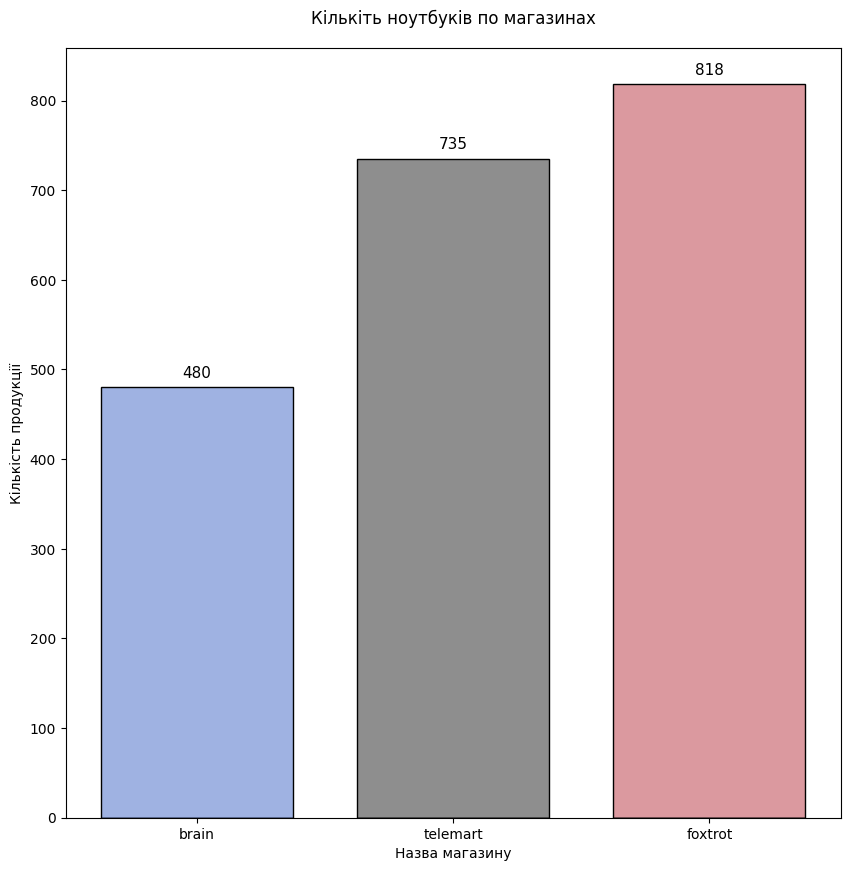

In [22]:
from typing import cast
import matplotlib.container as mcontainer


u = sorted(laptop_rating['shop'].unique())
color = sns.set_palette('icefire', len(u))

plt.figure(figsize=(10, 10))
ax = sns.histplot(
    x='shop', 
    data=laptop_rating, 
    hue='shop',
    shrink=0.75,
    palette=color,
    edgecolor='black',
    legend=False, 
)



for container in ax.containers:
    label = [int(v.get_height()) if v.get_height() > 0  else '' for v in container]
    ax.bar_label(
        cast(mcontainer.BarContainer, container),
        fontsize=11, 
        padding=5,
        label_type='edge', 
        labels=label,
        fmt='%d'
    )

plt.title("Кількіть ноутбуків по магазинах", y=1.02)
plt.xlabel("Назва магазину")
plt.ylabel("Кількість продукції")
plt.show()

## Середній рейтинговий показник для ноутбука 

In [23]:
laptop_rating.to_csv('laptop_rating.csv', index=False)

### Очищення Nan значень

In [24]:
df = laptop_rating
df[['cpu_rating', 'gpu_rating']] = df[['cpu_rating', 'gpu_rating']].fillna(0)

#### Формула  (cou_rating + gpu_rating) // 2

In [25]:
def get_avg_perf_score(cpu_rating: int | None, gpu_rating: int | None) -> int | None:
        # Перевірка чи є взагалі якийсь рейтинг
        if cpu_rating is None and gpu_rating is None:
            return

        # Якщо є тільки GPU
        if cpu_rating is None and gpu_rating is not None:
            return int(gpu_rating) if gpu_rating else gpu_rating
        # Якщо є тільки CPU
        elif cpu_rating is not None and gpu_rating is None:
            return int(cpu_rating) if cpu_rating else cpu_rating
        # Якщо є CPU & GPU
        else:
             return (cpu_rating + gpu_rating) // 2  # type: ignore


In [26]:
v_get_score = np.vectorize(get_avg_perf_score)
df["avg_perf_score"] = v_get_score(df['cpu_rating'], df['gpu_rating'])

#### Графік розподілу ноутбуків за ціною

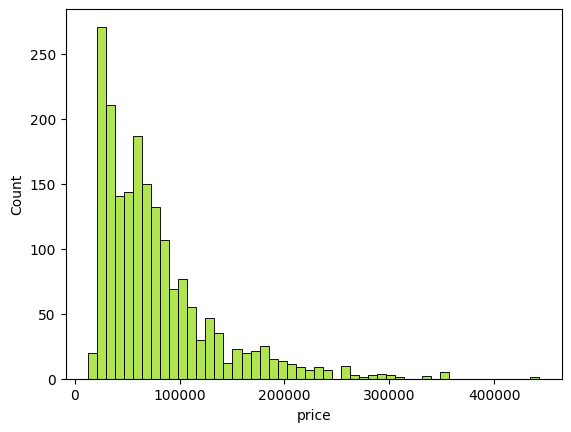

In [27]:
df = df.sort_values(by=['avg_perf_score', 'price'], ascending=True)
df = df[(df['cpu_name'].notna())].reset_index(drop=True)
sns.histplot(
    data=df,
    x='price',
    bins=50,
    color="#96DB15",
)
plt.show()

In [28]:
df[['cpu', 'cpu_name', "cpu_rating", 'gpu', 'gpu_name', 'gpu_rating', 'avg_perf_score', 'price']].sample(1)

,cpu,cpu_name,cpu_rating,gpu,gpu_name,gpu_rating,avg_perf_score,price
1470,Intel Core 5 120U,Intel Core 5 120U,1012.0,Intel Iris Xe Graphics G7,Intel Iris Xe Graphics G7,497.0,754.0,69999.0


#### Графік розподілу ноутбуків залежно від їх середньої продуктивності та ціни по магазинах

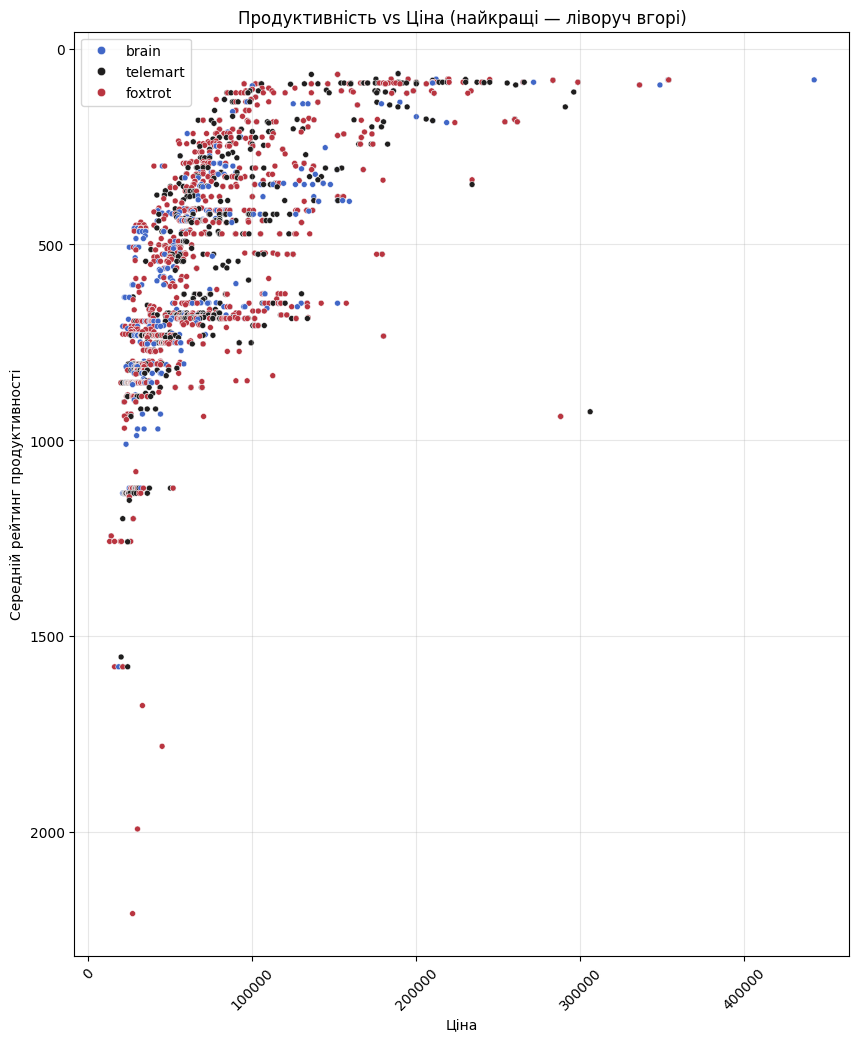

In [29]:
plt.figure(figsize=(10, 12))
ax = sns.scatterplot(
    data=df,
    x='price',
    y='avg_perf_score',
    hue='shop',
    size=1,
    palette='icefire'
)
plt.gca().invert_yaxis()

plt.title('Продуктивність vs Ціна (найкращі — ліворуч вгорі)')
plt.xlabel('Ціна')
plt.ylabel('Середній рейтинг продуктивності')

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:-1], labels[:-1])

plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.show()

## Аналіз RAM у ноутбуках

In [30]:
df['RAM'] = df['other'] \
        .apply(lambda x: get_spec(x, ["Об'єм оперативної пам'яті", "Обсяг", "Об'єм ОЗП"])) \
        .apply(lambda x: get_numetric(x)).fillna(0).astype(int)

### Розподіл RAM у ноутбуках

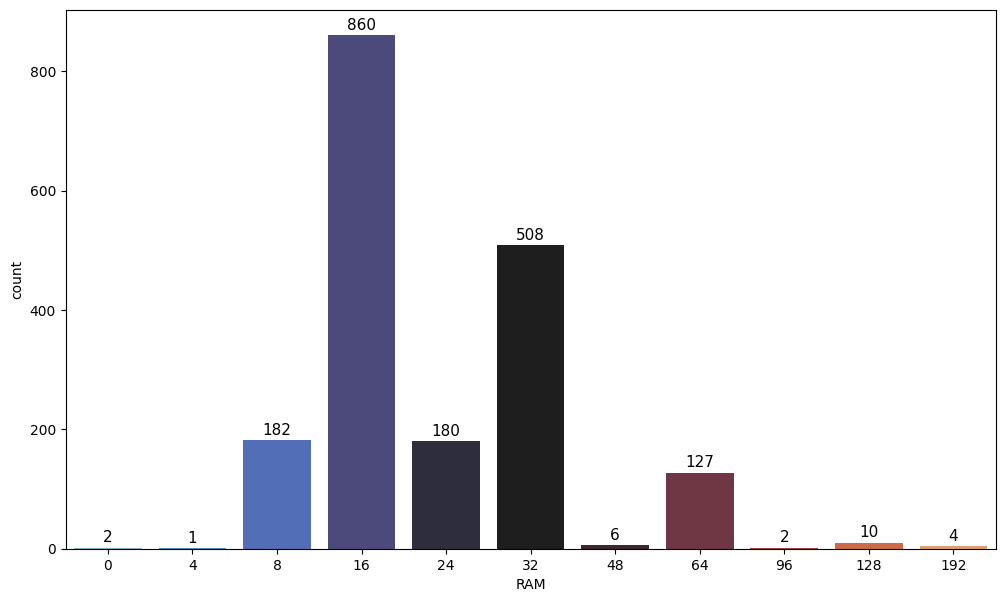

In [31]:
ram_order = sorted(df['RAM'].unique())
colors = sns.color_palette("icefire", len(ram_order))

plt.figure(figsize=(12, 7))
ax = sns.countplot(
    data=df,
    x='RAM',
    order=ram_order,
    hue='RAM',
    palette=colors,
    legend=False
)

for container in ax.containers:
    label = [
        int(v.get_height())
        if v.get_height() > 0 else ''
        for v in container
    ]

    ax.bar_label(
        cast(mcontainer.BarContainer, container),
        fontsize=11, 
        padding=2,
        label_type='edge', 
        label = label,
        fmt='%d'
    )

plt.show()


### Ціна за 1 гіг RAM

**Formula:**  (price / RAM)

In [32]:
df_ram = df[df['RAM']!=0]
df_ram['price_to_ram'] = round(df_ram['price'] / df_ram['RAM'], 2)

In [33]:
df_ram[['shop', 'product_code', 'laptop_name', 'price', 'RAM', 'price_to_ram', 'avg_perf_score']] \
    .sort_values(by=['price_to_ram', 'avg_perf_score', 'price'], ascending=[False, False, False]).head()

,shop,product_code,laptop_name,price,RAM,price_to_ram,avg_perf_score
1776,telemart,653806,Durabook Z14 Basic Black,305999.0,16,19124.94,927.0
1788,telemart,653805,Durabook Z14 Basic Black,287999.0,16,17999.94,939.0
1789,foxtrot,7008561,DURABOOK Z14 Basic Black,287999.0,16,17999.94,939.0
595,brain,U0929740,Dell XPS 16 9640,159156.0,16,9947.25,390.0
594,brain,U0999883,Dell XPS 14 9440,140474.0,16,8779.62,390.0


#### RAM на графіку ціна vs продуктивність

In [34]:
avg_score = df_ram.groupby('RAM')[['avg_perf_score', 'price']].mean().round(2)
avg_score = avg_score.reset_index()

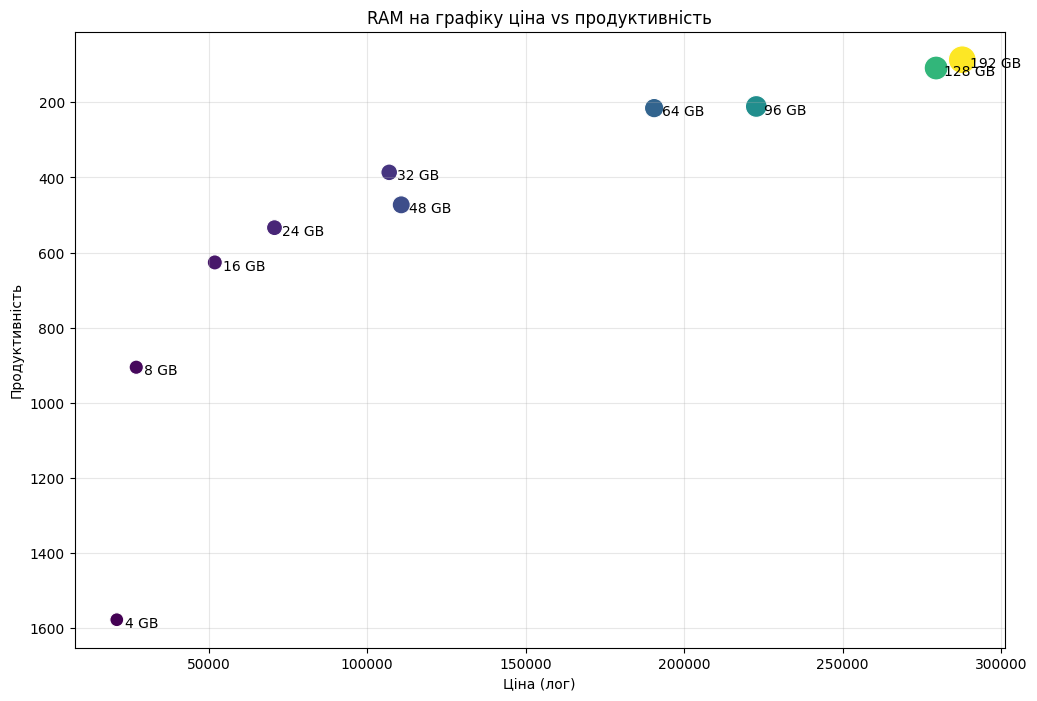

In [35]:
color = sns.color_palette('viridis', len(ram_order))

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=avg_score,
    x='price',
    y='avg_perf_score', 
    hue='RAM', 
    size='RAM', 
    sizes=(100, 400), 
    palette='viridis', 
    legend=False
)

for i in range(len(avg_score)):
    plt.text(avg_score['price'].iloc[i]+2500, avg_score['avg_perf_score'].iloc[i]+20, 
             f"{avg_score['RAM'].iloc[i]} GB", fontsize=10)

plt.title('RAM на графіку ціна vs продуктивність')
plt.xlabel('Ціна (лог)')
plt.ylabel('Продуктивність')

plt.grid(True, alpha=0.3)
plt.gca().invert_yaxis()
plt.show()

## Роздільна здатність дисплею

#### Фунція для отримання кількості пікселів

In [36]:
def get_total_pixels(resolution: str) -> int | None:
    r = get_numetric(resolution, first_only=False)
    h, w = r[0], r[1]
    try:
        return int(h) * int(w)
    except ValueError:
        return None

In [37]:
df['resolution'] = df['other'] \
    .apply(lambda x: get_spec(x, ['Роздільна здатність', 'Роздільна здатність дисплея', 'Роздільність']))
df['total_pixels'] = df['resolution'].apply(lambda x: get_total_pixels(x)).astype(int)

Мапування роздільної здатності

In [38]:
resolution_dict = {
    1049088: "HD",
    2073600: "Full HD",
    2304000: "Full HD+",
    2457600: "Full HD+",
    2621440: "2K DCI",
    3136000: "WUX+",
    3657600: "WQHD",
    3686400: "WQHD",
    4096000: "WQXGA",
    4665600: "3K",
    5184000: "3K/Retina",
    5628000: "WQXGA+",
    8294400: "4K UHD",
    9216000: "4K UHD+"
}

#### Графік розподіл ноутбуків за роздільною здатністю

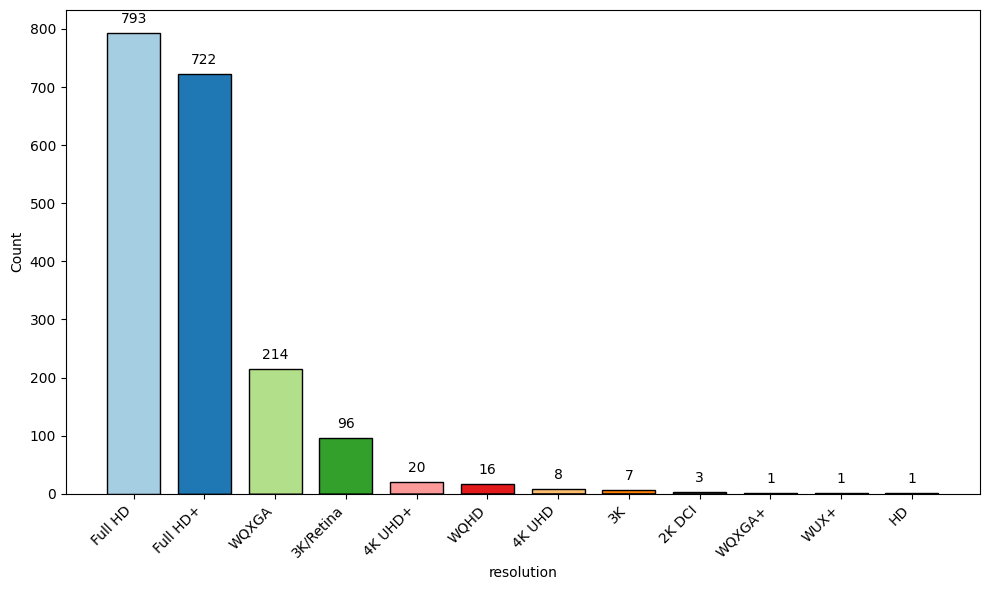

In [76]:
import matplotlib.ticker as ticker

df['resolution'] = df['total_pixels'].map(resolution_dict).fillna("Other")

res_order = sorted(df['resolution'].unique(), reverse=True)                                 # кількіть всіх resolutions для розподілу кольорів та лейблів
set_order = df['resolution'].value_counts().sort_values(ascending=False).index.to_list()    # список для розподілу більшого до меншого

df['resolution'] = pd.Categorical(df['resolution'], categories=set_order, ordered=True)     
colors = sns.color_palette('Paired', len(res_order))


plt.figure(figsize=(10, 6))
ax = sns.histplot(
    data=df,
    x='resolution',
    hue='resolution',
    palette=colors,
    legend=False,
    edgecolor='black',
    shrink=0.75,
    alpha=1
)

# Прибираємо всі поточні мітки і встановлюємо вручну
ax.set_xticks(range(len(res_order)))
ax.set_xticklabels(set_order, rotation=45, ha='right')

for container in ax.containers:
    labels = [int(v.get_height()) if v.get_height() > 0 else '' for v in container]
    ax.bar_label(cast(mcontainer.BarContainer, container), labels=labels, fontsize=10, label_type='edge', padding=5)



plt.tight_layout()
plt.show()

#### Ціна за 1 pixel

**Formula:** price_to_pixel = round(price / total_pixels

In [41]:
df['price_to_pixel'] = round(df['price'] / df['total_pixels'], 3)

In [42]:
avg_score = df.groupby('resolution')['price_to_pixel'].mean().round(3)
avg_score

resolution
Full HD      0.021
Full HD+     0.035
WQXGA        0.036
3K/Retina    0.024
4K UHD+      0.027
WQHD         0.025
4K UHD       0.022
3K           0.016
2K DCI       0.050
WQXGA+       0.015
WUX+         0.039
HD           0.012
Name: price_to_pixel, dtype: float64

In [43]:
u = df['resolution'].value_counts()
un = u[u>=15].index.to_list()

#### Щільність розподілу ціни за піксель для різних роздільних здатностей

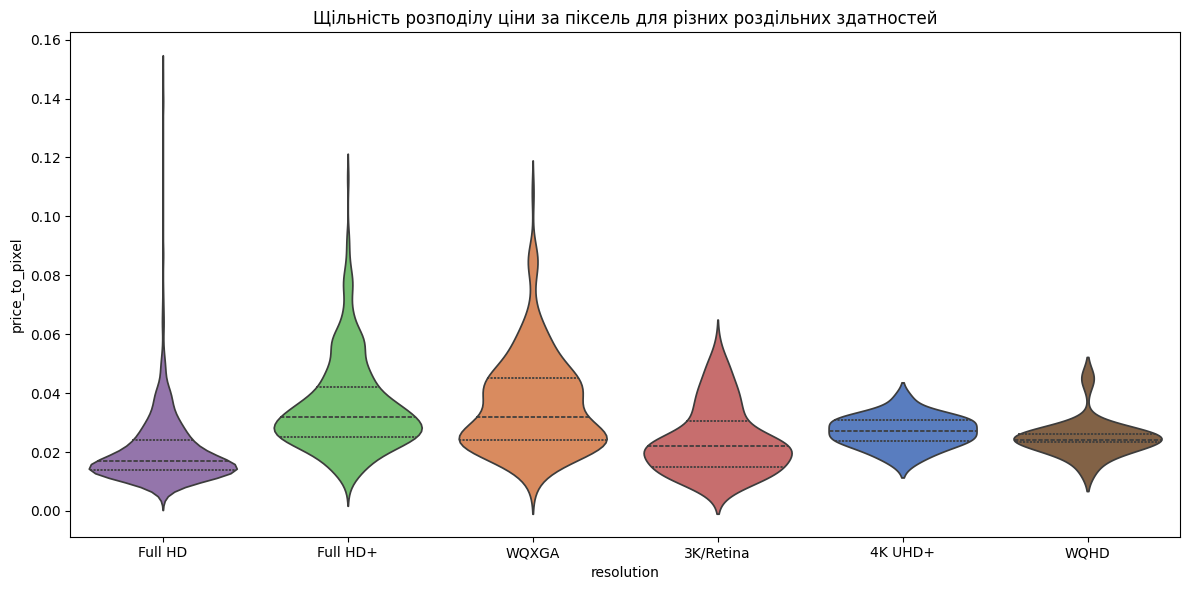

In [44]:
plt.figure(figsize=(12, 6))

sub_df = df[df['resolution'].isin(un)]
sub_df['resolution'] = sub_df['resolution'].cat.remove_unused_categories()

ax = sns.violinplot(
    data=sub_df,
    x='resolution',
    hue='resolution',
    y='price_to_pixel',
    palette='muted',
    inner='quartile',
    legend=False,
    dodge=False
)

ax.set_xticks(range(len(un)))


plt.title('Щільність розподілу ціни за піксель для різних роздільних здатностей')
plt.tight_layout()
plt.show()

## Виробник

In [45]:
df['brand'] = df['other'].apply(lambda x: get_spec(x, ['Бренд', 'Модельний ряд', 'Виробник'])).str.capitalize()

In [46]:
manufacturers = [
    "LENOVO",
    "ASUS",
    "ACER",
    "APPLE",
    "HP",
    "HP",
    "DREAM MACHINES",
    "DELL",
    "GIGABYTE",
    "MSI",
    "PIXUS",
    "VINGA",
    "2E",
    "AGN",
    "BLACKVIEW",
    "DURABOOK",
    "PROLOGIX",
    "THOMSON",
    "THUNDEROBOT"
]

In [47]:
def clean_brand(string: str, brand_list: List[str] = manufacturers) -> str | None:
    if isinstance(string, str):
        return next((s.capitalize() for s in brand_list if s.upper() in string.upper()), '1')
    return None

In [48]:
df.loc[df['shop'] == 'foxtrot', 'brand'] = df.loc[df['shop'] == 'foxtrot', 'laptop_name'].apply(clean_brand)
df['brand'].value_counts()

brand
Hp                1051
Lenovo             183
Acer               168
Asus               141
Msi                 71
Prologix            66
Dream machines      64
Dell                64
Gigabyte            28
Thunderobot         14
Vinga               13
2e                   9
Pixus                4
Agn                  3
Durabook             3
Name: count, dtype: int64

### Графік розподілу кількості ноутбуках залежно від бренду

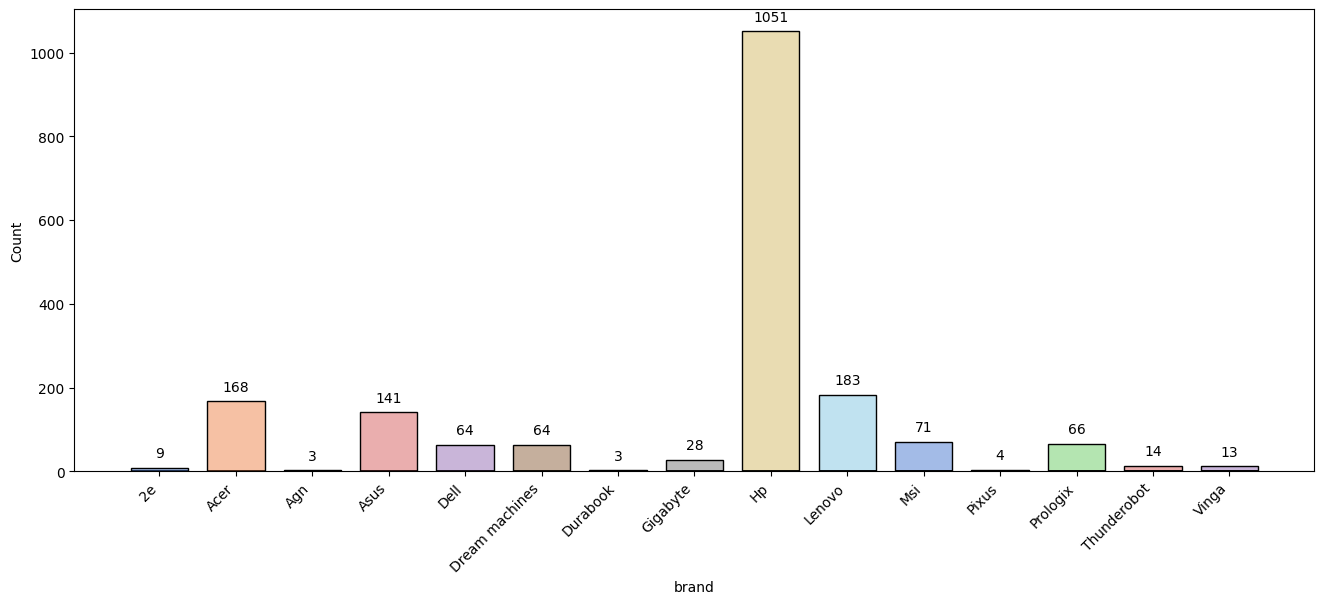

In [49]:
unique_brand = sorted(df['brand'].unique())
df['brand'] = pd.Categorical(df['brand'], categories=unique_brand, ordered=True)

plt.figure(figsize=(16, 6))
ax = sns.histplot(
    data=df,
    x='brand',
    hue='brand',
    palette='muted',
    legend=False,
    shrink=0.75
)

ax.set_xticks(range(len(unique_brand)))
ax.set_xticklabels(unique_brand, rotation=45, ha='right')


for container in ax.containers:
    label = [int(h.get_height()) if h.get_height() > 0 else '' for h in container]
    plt.bar_label(
        cast(mcontainer.BarContainer, container),
        labels=label,
        padding=5,
        fmt='%d',
        label_type='edge',
        fontsize=10
    )
plt.show()

### Медіанна ціни для бренду

In [50]:
medprice = df.groupby('brand')[['price', 'avg_perf_score']].agg(median_price=('price', 'median'), perfomance=('avg_perf_score', 'mean')).reset_index().round(3)
medprice

,brand,median_price,perfomance
0,2e,35499.0,793.667
1,Acer,64999.0,426.387
2,Agn,96844.0,874.000
3,Asus,58999.0,486.865
4,Dell,50532.0,766.594
5,Dream machines,89999.0,201.484
6,Durabook,287999.0,935.000
7,Gigabyte,72167.0,309.821
8,Hp,66055.0,578.076
9,Lenovo,49999.0,588.601


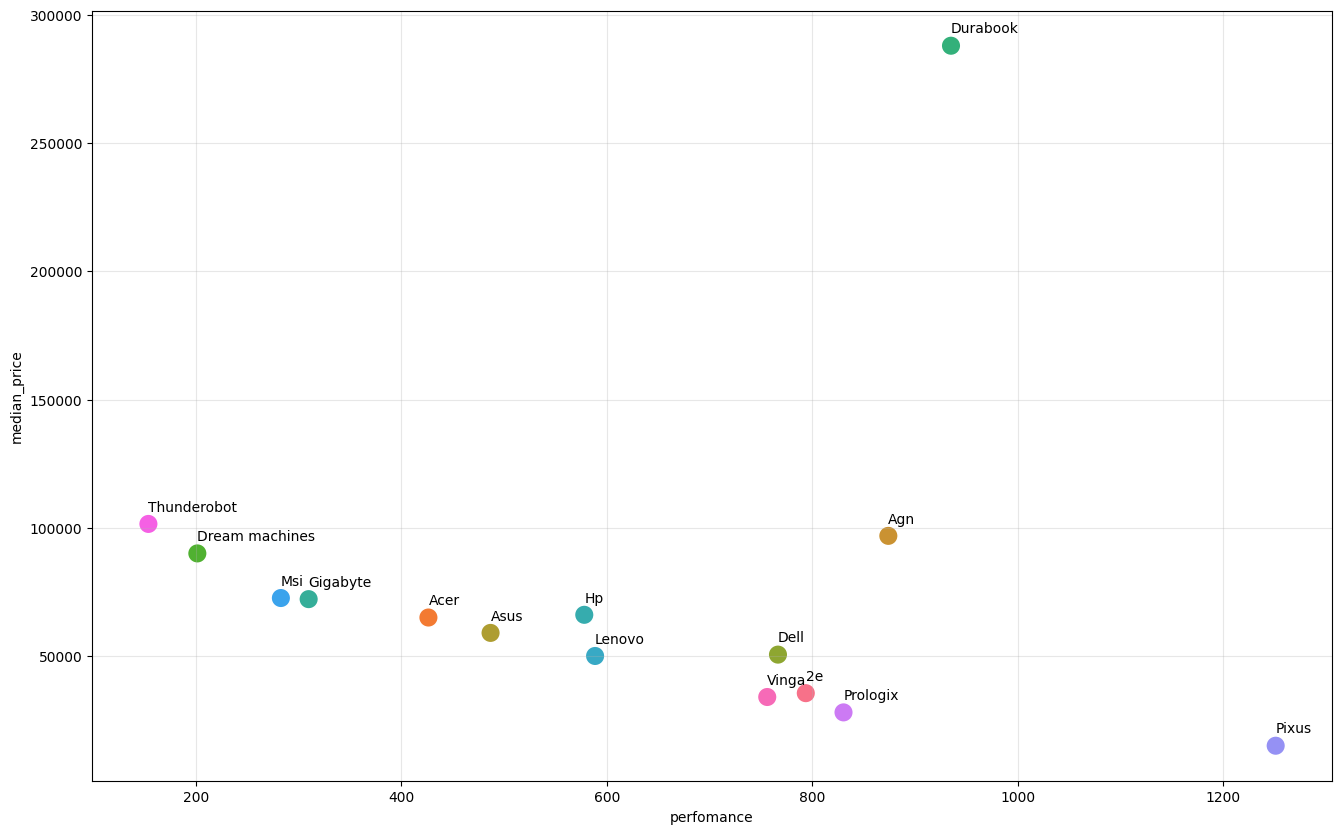

In [51]:
plt.figure(figsize=(16, 10))

ax = sns.scatterplot(
    data=medprice,
    x='perfomance',
    hue='brand',
    y='median_price',
    palette=None,
    legend=False,
    size=200,
    sizes=(200, 400)
)

for i in range(len(medprice)):
    plt.text(
        x=medprice['perfomance'].iloc[i],
        y=medprice['median_price'].iloc[i]+5000,
        s=medprice['brand'].iloc[i],
        fontsize=10
    )

plt.title("")

plt.grid(True, alpha=0.3)
plt.show()

# Категоризація даних

In [52]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1882 entries, 0 to 1881
Data columns (total 29 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   laptop_name      1882 non-null   str     
 1   price            1882 non-null   float64 
 2   product_code     1882 non-null   str     
 3   shop             1882 non-null   str     
 4   product_url      1882 non-null   str     
 5   cpu              1882 non-null   str     
 6   gpu              1882 non-null   str     
 7   other            1882 non-null   str     
 8   cpu_rating       1882 non-null   float64 
 9   cpu_name         1882 non-null   str     
 10  device_type_cpu  1882 non-null   str     
 11  performance_cpu  1882 non-null   float64 
 12  year_cpu         1859 non-null   float64 
 13  tdp_cpu          1880 non-null   float64 
 14  cores            1875 non-null   float64 
 15  threads          1875 non-null   float64 
 16  gpu_rating       1882 non-null   float64 
 17  gpu_na

In [54]:
df.describe()

,price,cpu_rating,performance_cpu,year_cpu,tdp_cpu,cores,threads,gpu_rating,performance_gpu,year_gpu,tdp_gpu,avg_perf_score,RAM,total_pixels,price_to_pixel
count,1882.000000,1882.000000,1882.000000,1859.000000,1880.000000,1875.000000,1875.000000,1882.000000,1713.000000,1713.000000,1122.000000,1882.000000,1882.000000,1.882000e+03,1882.000000
mean,77602.370882,801.181722,13.512173,2023.983862,29.440957,10.582400,14.346667,294.613709,29.012680,2023.875073,131.795900,547.622742,24.682253,2.679160e+06,0.028527
std,54744.516518,408.733541,7.380668,1.259093,14.835365,5.347179,5.733622,226.522463,26.098294,2.003103,139.773157,284.625180,17.451992,1.172623e+06,0.015722
min,12999.000000,122.000000,0.160000,2005.000000,6.000000,1.000000,1.000000,0.000000,2.870000,2014.000000,15.000000,64.000000,0.000000,1.049088e+06,0.007000
25%,37255.000000,473.000000,8.560000,2023.000000,15.000000,6.000000,12.000000,55.000000,11.620000,2023.000000,15.000000,327.000000,16.000000,2.073600e+06,0.017000
50%,62999.000000,859.000000,10.830000,2024.000000,28.000000,10.000000,14.000000,393.000000,13.470000,2025.000000,55.000000,543.000000,16.000000,2.304000e+06,0.025000
75%,96999.000000,1050.000000,16.660000,2025.000000,45.000000,14.000000,16.000000,453.000000,41.510000,2025.000000,180.000000,738.000000,32.000000,2.304000e+06,0.035000
max,442599.000000,3591.000000,35.640000,2026.000000,55.000000,24.000000,32.000000,826.000000,100.000000,2026.000000,600.000000,2208.000000,192.000000,9.216000e+06,0.148000


# МЛ навчання та прогнозування

In [55]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error

### Налаштування колонок та визначення X & y параметрів

In [103]:
features = [
    'shop', 'cpu_rating', 'gpu_rating', 'performance_cpu',
    'performance_gpu', 'year_cpu', 'year_gpu', 'architecture', 'RAM', 'resolution',
    'brand'
]

cat_cols = ['shop', 'architecture', 'brand', 'resolution']
num_cols = [col for col in features if col not in cat_cols]

X = df[features].copy()
X[cat_cols] = X[cat_cols].astype(object).fillna('missing')
X[num_cols] = X[num_cols].fillna(0)
y = df['price'].fillna(df['price'].median())

Перетворення категоріальних даних

In [104]:
X = pd.get_dummies(X, columns=cat_cols, drop_first=True).astype(float).fillna(0)

Розподіл вибірки

In [105]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

In [106]:
scaler = StandardScaler()

X_train_scal = scaler.fit_transform(X_train)
X_test_scal = scaler.transform(X_test)

### Створення лінійної моделі

In [107]:
model = LinearRegression()

model.fit(X_train_scal, y_train)
y_pred = model.predict(X_test_scal)

print("R2 score:", r2_score(y_test, y_pred))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))

results = pd.DataFrame({
    "actual_price": y_test,
    "predicted_price": y_pred,
    "error": y_test - y_pred,
    "error_pct": (y_test - y_pred) / y_test.abs() * 100
})

display(results.sample(10, random_state=1))

R2 score: 0.8896282481275157
Mean Absolute Error: 13308.437549135626


,actual_price,predicted_price,error,error_pct
1482,43999.0,31833.881453,12165.118547,27.648625
484,76599.0,73820.711199,2778.288801,3.627056
120,98499.0,151988.898891,-53489.898891,-54.305017
163,101999.0,144345.414919,-42346.414919,-41.516500
1710,30499.0,38783.748823,-8284.748823,-27.164002
1649,23999.0,10092.589187,13906.410813,57.945793
821,73899.0,59690.800322,14208.199678,19.226511
1323,74442.0,65146.051606,9295.948394,12.487505
345,73999.0,80600.846881,-6601.846881,-8.921535
593,140155.0,94313.596483,45841.403517,32.707648


### Визначення ваги коефіцієнтів

In [108]:
weights_dif = {
    "coloum": X.columns,
    "weight": model.coef_
}

wdf = pd.DataFrame(weights_dif).sort_values(by='weight', ascending=False)
wdf

,coloum,weight
6,RAM,22699.591443
2,performance_cpu,21442.034030
3,performance_gpu,18926.995628
1,gpu_rating,17149.667728
27,brand_Durabook,9464.115674
29,brand_Hp,7147.973543
0,cpu_rating,4493.439638
25,brand_Dell,3491.335391
23,brand_Agn,1891.215866
35,brand_Vinga,1719.420729


In [109]:
f = 6
most = pd.concat([wdf.head(f), wdf.tail(f)], ignore_index=True)
most

,coloum,weight
0,RAM,22699.591443
1,performance_cpu,21442.034030
2,performance_gpu,18926.995628
3,gpu_rating,17149.667728
4,brand_Durabook,9464.115674
5,brand_Hp,7147.973543
6,architecture_RDNA 3.0,-8290.109307
7,resolution_Full HD+,-10789.091127
8,architecture_RDNA 2.0,-11519.538491
9,architecture_missing,-11870.950646


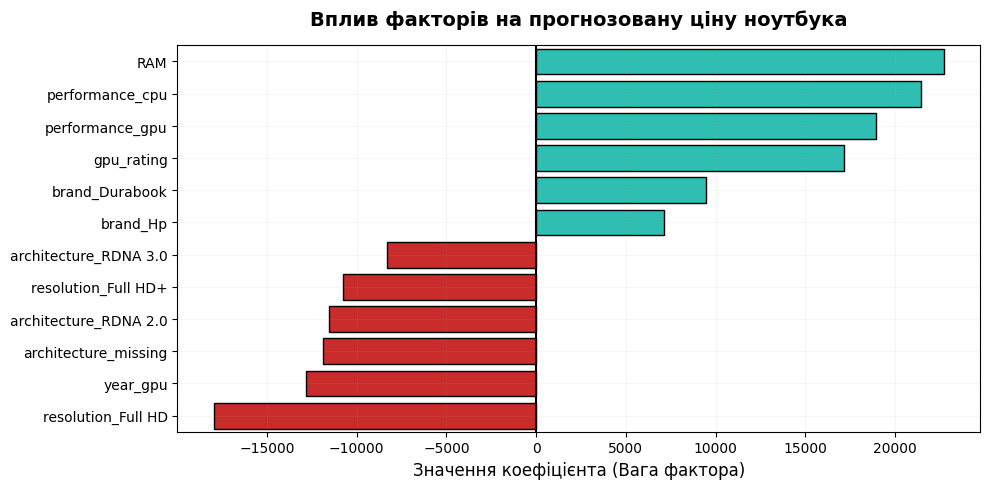

In [130]:
most['positive'] = most['weight'] > 0


plt.figure(figsize=(10, 5))
sns.barplot(
    data=most,
    x='weight',
    y='coloum',
    hue='positive',
    palette={True:"#17D6C600", False:"#E41111"},
    legend=False,
    edgecolor='black'
)

plt.axvline(x=0, color='black', linestyle='-', linewidth=1.5)
plt.grid(True, alpha=0.1)

plt.title('Вплив факторів на прогнозовану ціну ноутбука', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Значення коефіцієнта (Вага фактора)', fontsize=12)
plt.ylabel('', fontsize=12)

plt.tight_layout()
plt.show()